<a href="https://colab.research.google.com/github/bdipesh3045/Data-Science-project-AI-Class-/blob/main/main1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
%pip install -q "kagglehub[pandas-datasets]" scikit-learn matplotlib

import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

In [11]:

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "datamunge/sign-language-mnist",
    "sign_mnist_train.csv"
)

df.head()

/tmp/ipykernel_479/3075838219.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sign-language-mnist' dataset.


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


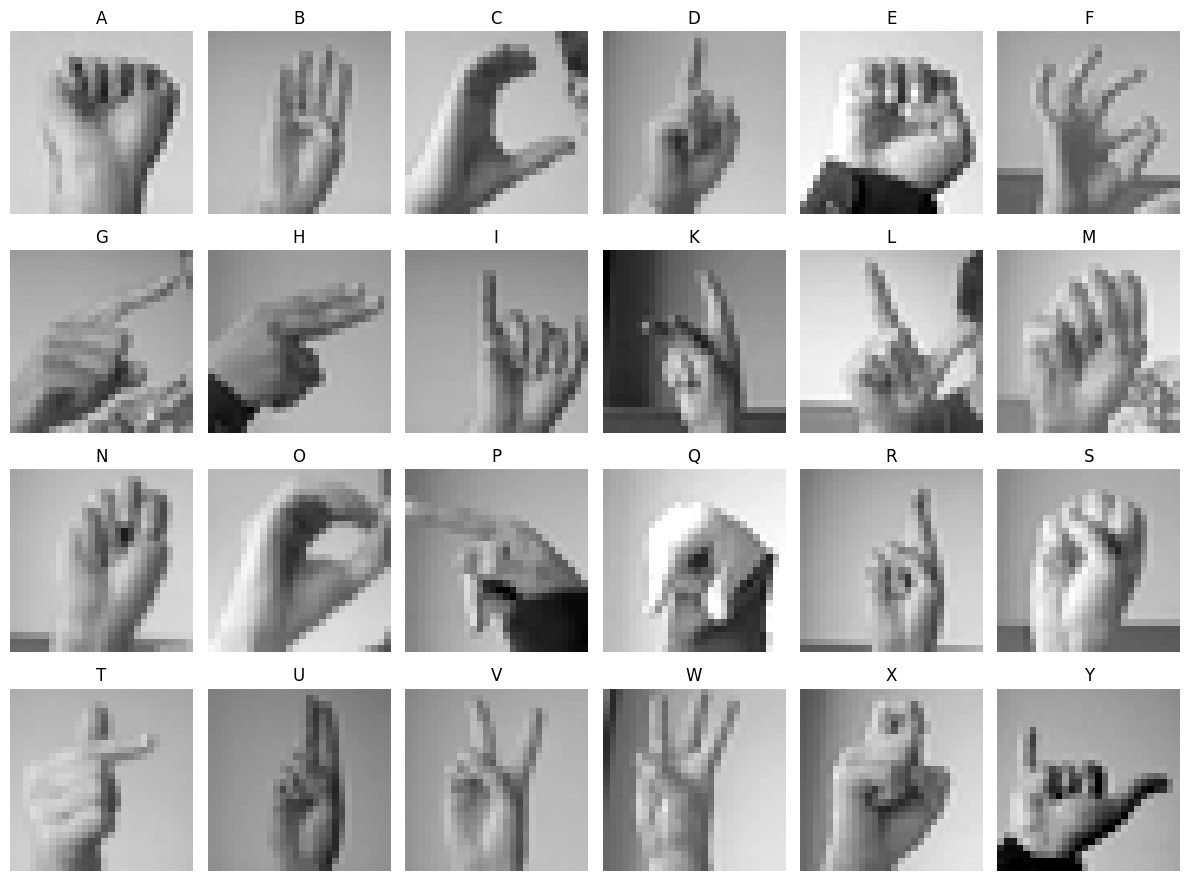

In [12]:
# Find all the letter labels in the dataset
labels = sorted(df["label"].unique())

plt.figure(figsize=(12, 9))

# Display one image for each letter
for i, label in enumerate(labels):
    row = df[df["label"] == label].iloc[0]

    # Arrange the 784 pixels into a 28 × 28 image
    image = row.drop("label").to_numpy().reshape(28, 28)

    plt.subplot(4, 6, i + 1)
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title(chr(65 + int(label)))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
X = df.drop("label", axis=1).to_numpy() / 255.0
y = df["label"].to_numpy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))

Training images: 21964
Validation images: 5491


In [14]:
model = SVC(kernel="rbf")

print("Training started...")

model.fit(X_train, y_train)

print("Training finished!")

Training started...
Training finished!
